In [ ]:
import torch
import pandas as pd
from transformers import BertTokenizer, BertModel
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/final_rabies_data (1).csv", encoding='latin-1')
df.drop("Unnamed: 0" , axis = 1, inplace = True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6774 entries, 0 to 6773
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        6774 non-null   object
 1   sequence  6774 non-null   object
 2   Host      6763 non-null   object
dtypes: object(3)
memory usage: 158.9+ KB


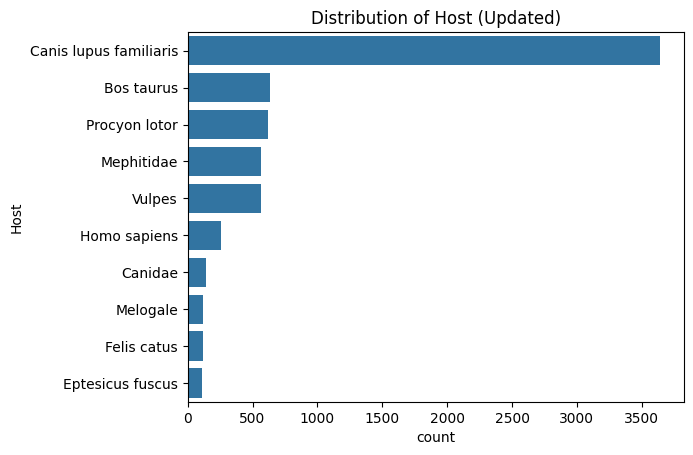

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

df['Host'] = df['Host'].replace(['Vulpes vulpes', 'Vulpes lagopus'], 'Vulpes')
df['Host'] = df['Host'].replace('Mephitis mephitis', 'Mephitidae')

plt.figure()
sns.countplot(df["Host"], order = df["Host"].value_counts().index)
plt.title("Distribution of Host (Updated)")
plt.show()

In [ ]:
df.to_csv("updated_rabies_data.csv", index = False)

In [ ]:
tokenizer = BertTokenizer.from_pretrained("Rostlab/prot_bert", do_lower_case=False)
model = BertModel.from_pretrained("Rostlab/prot_bert").to(device)
model.eval()

def batch_embed(sequences, batch_size=16):
    embeddings = []
    for i in tqdm(range(0, len(sequences), batch_size)):
        batch_seqs = [" ".join(list(seq)) for seq in sequences[i:i+batch_size]]
        tokens = tokenizer(batch_seqs, return_tensors="pt", padding=True, truncation=True, max_length = 524).to(device)
        with torch.no_grad():
            output = model(**tokens)
        batch_emb = output.last_hidden_state.mean(dim=1).cpu().numpy()
        embeddings.extend(batch_emb)
    return embeddings

df["embeddings"] = batch_embed(df["sequence"].tolist(), batch_size=16)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/86.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/81.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/361 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.68G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.68G [00:00<?, ?B/s]


100%|██████████| 424/424 [13:53<00:00,  1.96s/it]


In [ ]:
len(df["embeddings"][10])

1024

In [ ]:
import numpy as np
from sklearn.decomposition import PCA

X = np.vstack(df["embeddings"].values)

X_df = pd.DataFrame(X, columns=[f"feat_{i}" for i in range(X.shape[1])])

In [ ]:
X_df.to_csv("embeddings.csv")

In [ ]:
pca = PCA(n_components=10, random_state=42)
X_pca = pca.fit_transform(X)

PCA_df = pd.DataFrame(X_pca, columns=[f"pca_{i}" for i in range(10)])

PCA_df.sample(5)

,pca_0,pca_1,pca_2,pca_3,pca_4,pca_5,pca_6,pca_7,pca_8,pca_9
4731,0.051607,0.026972,0.019887,0.013889,-0.032586,0.041039,0.033216,-0.033631,-0.028862,0.025811
4095,0.119049,-0.114715,0.018021,0.016783,0.029484,-0.015730,0.033408,0.024483,-0.035319,0.001482
1710,0.164824,0.068520,0.030614,0.021730,-0.065584,0.009717,0.005050,-0.008028,-0.017135,-0.006422
5477,0.409723,-0.079015,-0.005065,-0.021409,-0.029532,-0.003072,-0.021807,-0.011865,0.027784,0.004174
2734,-0.788169,-0.236346,-0.022727,-0.010848,0.008380,-0.003408,-0.009336,-0.016269,-0.000333,-0.013679


In [ ]:
df.drop("embeddings", axis = 1, inplace = True)
df = pd.concat([df, PCA_df], axis = 1)

df.head()

,id,sequence,Host,pca_0,pca_1,pca_2,pca_3,pca_4,pca_5,pca_6,pca_7,pca_8,pca_9
0,BFZ76643.1,MIPQVLLFVPLLVFSSCFGKFPIYTIPDKLGPWSPIDIHHLSCPNN...,Homo sapiens,0.106644,-0.107226,0.019644,0.017027,0.028785,-0.015736,0.030065,0.025175,-0.038013,-0.000475
1,BFZ76648.1,MIPQVLLFVPLLVFSSCFGKFPIYTIPDKLGPWSPIDIHHLSCPNN...,Homo sapiens,0.119049,-0.114716,0.018021,0.016783,0.029486,-0.015731,0.033411,0.024482,-0.035317,0.001483
2,BFZ76653.1,MIPQVLLFVPLLVFSSCFGKFPIYTIPDKLGPWSPIDIHHLSCPNN...,Homo sapiens,0.113497,-0.112016,0.018896,0.016447,0.030120,-0.017453,0.034994,0.024927,-0.033269,-0.000157
3,BFZ76658.1,MIPQVLLFVPLLVFSSCFGKFPIYTIPDKLGPWSPIDIHHLSCPNN...,Canis lupus familiaris,0.147459,-0.105213,0.014622,0.009625,0.034623,-0.019460,0.031782,0.023305,-0.018860,0.000942
4,BFZ76663.1,MIPQVLLFVPLLVFSSCFGKFPIYTIPDKLGPWSPIDIHHLSCPNN...,Canis lupus familiaris,0.122030,-0.111838,0.017666,0.016175,0.025688,-0.014404,0.032326,0.024245,-0.035777,0.001708


In [ ]:
df.to_csv("PCA_transformed_final_data.csv")